# **Lab3: Data Quality & Preprocessing**

**Course**: **INF-604: Data Analysis I** <br>
**Lecturer**: **Sothea HAS, PhD**

-----

**Objective:** In this lab, you will delve deeper into assessing the quality of datasets and employing preprocessing techniques to properly clean them.

------

* Name: ART OUDOM
* ID: 2025577


------

# 1. [Kaggle Heart Failure Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

Let's consider **Heart Disease Dataset** dataset discussed in the previous [Lab2](https://hassothea.github.io/Data_Analysis_AUPP/Labs/Lab2_Univariate_Analysis.html).

In [106]:
#| echo: true
#| code-fold: true

import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
data = pd.read_csv(path + "/heart.csv")
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**A.** Using quick statistical summary of each columns, identify the following problems:

- Encode each column into its suitable data type.
- Detect missing values using `data.isna().sum()`. What do you observe?
- Identify columns with invalid values. Count how many invalid data are there in each column?

--------------

In [107]:
# A.1 Data Type
data.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [108]:
data['FastingBS'] = data['FastingBS'].astype(object)
data['HeartDisease'] = data['HeartDisease'].astype(object)
data.dtypes.to_frame().T

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,int64,object,object,int64,int64,object,object,int64,object,float64,object,object


In [109]:
# Check missing values using .isna().sum()

data.isna().sum().to_frame().T  # there is no missing values that are encoded as Nan.

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0,0,0,0,0,0,0,0,0,0,0,0


In [110]:
# Invalid values
data.describe()   # THis is to get all the statistical summaries of the numerical columns.

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


- According to the summary, there are some invalid values within column: 'RestingBP', 'Cholesterol' and 'Oldpeak'.

In [111]:
# Count
sum(data['RestingBP'] == 0) # There is only 1 person with 0 RestingBP.

1

In [112]:
data.query("Cholesterol == 0").shape[0]

172

In [113]:
data.query("Oldpeak < 0").shape[0]

13

**B. From now, convert invalid data using `NA` encoding.**

- Study its nature: **MCAR, MAR** or **MNAR**? [`Hint`: You should compuare the clean columns before and after dropping the currupted values.]
- Handle them according to your analysis.
- *Outliers*: How many columns contain outliers? List them in a list called `outlier_list = [...]`.

In [114]:
import numpy as np
data.loc[data['RestingBP'] == 0, 'RestingBP'] = np.nan
data.loc[data['Cholesterol'] == 0, 'Cholesterol'] = np.nan
data.loc[data['Oldpeak'] < 0, 'Oldpeak'] = np.nan

In [115]:
qual_cols = data.select_dtypes(include='object').columns.to_list()
qual_cols


['Sex',
 'ChestPainType',
 'FastingBS',
 'RestingECG',
 'ExerciseAngina',
 'ST_Slope',
 'HeartDisease']

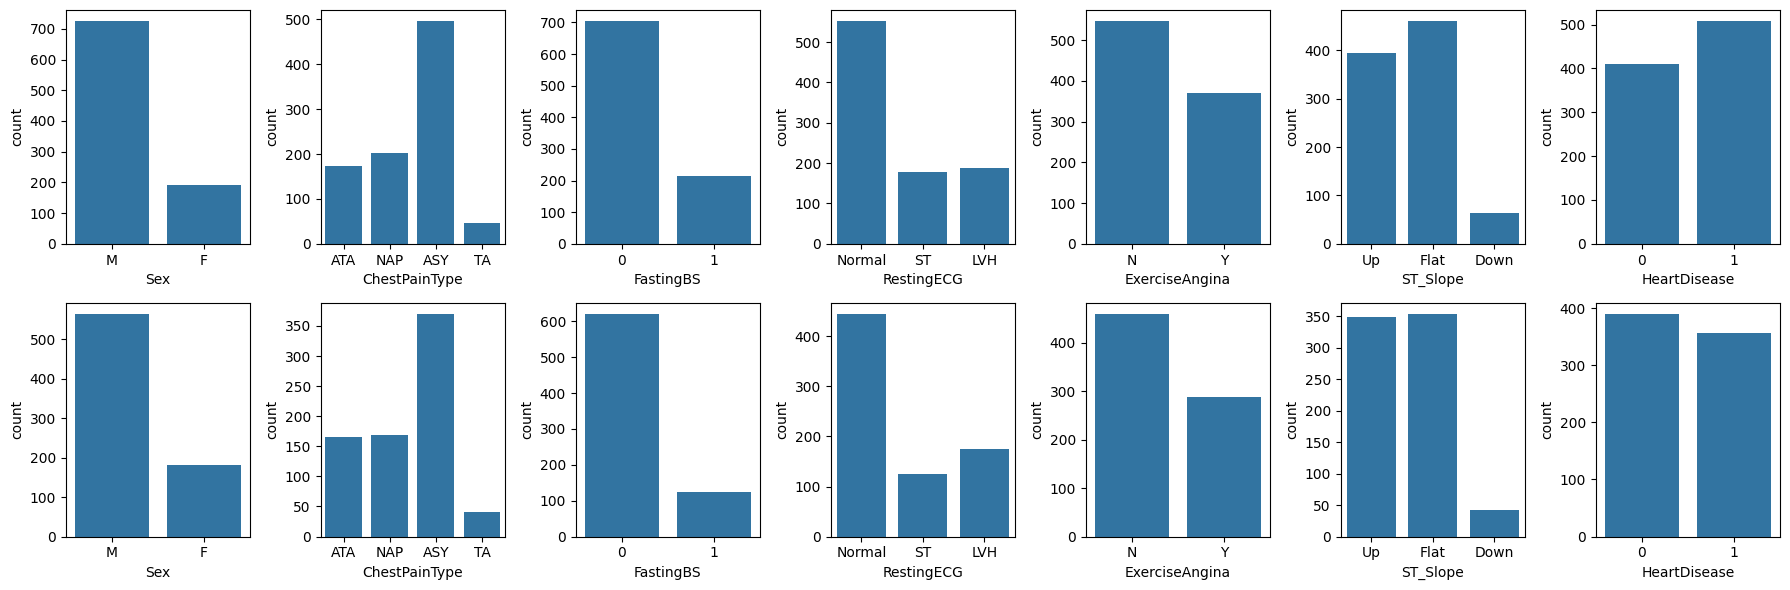

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 7, figsize=(18,6))
for i, col in enumerate(qual_cols):
  sns.countplot(
      data, 
      x = col,
      ax = axes[0,i]
  )
  sns.countplot(
      data.query("Cholesterol > 0"), # No 0 cholesterol individuals
      x = col,
      ax = axes[1,i]
  )

plt.tight_layout()

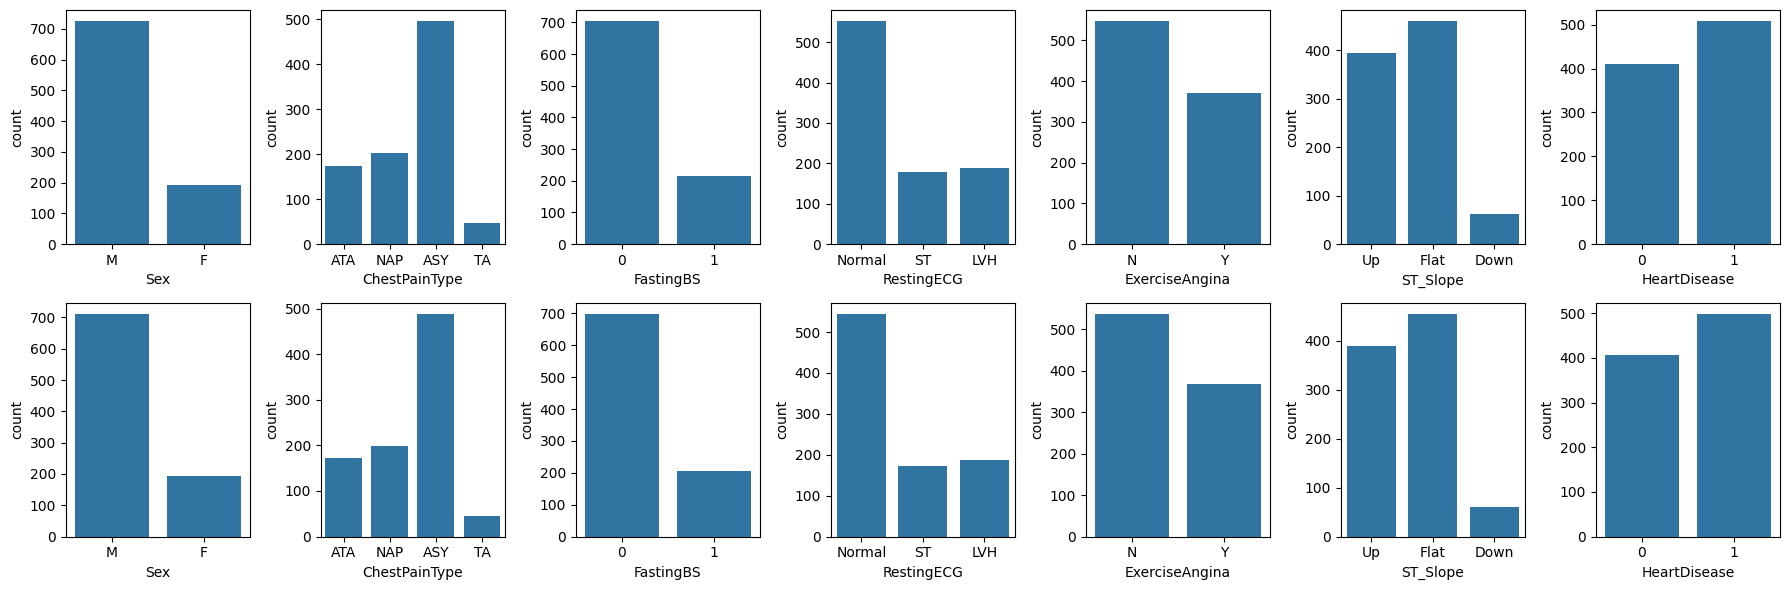

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 7, figsize=(18,6))
for i, col in enumerate(qual_cols):
  sns.countplot(
      data, 
      x = col,
      ax = axes[0,i]
  )
  sns.countplot(
      data.query(" Oldpeak >= 0"), # No 0 cholesterol individuals
      x = col,
      ax = axes[1,i]
  )

plt.tight_layout()

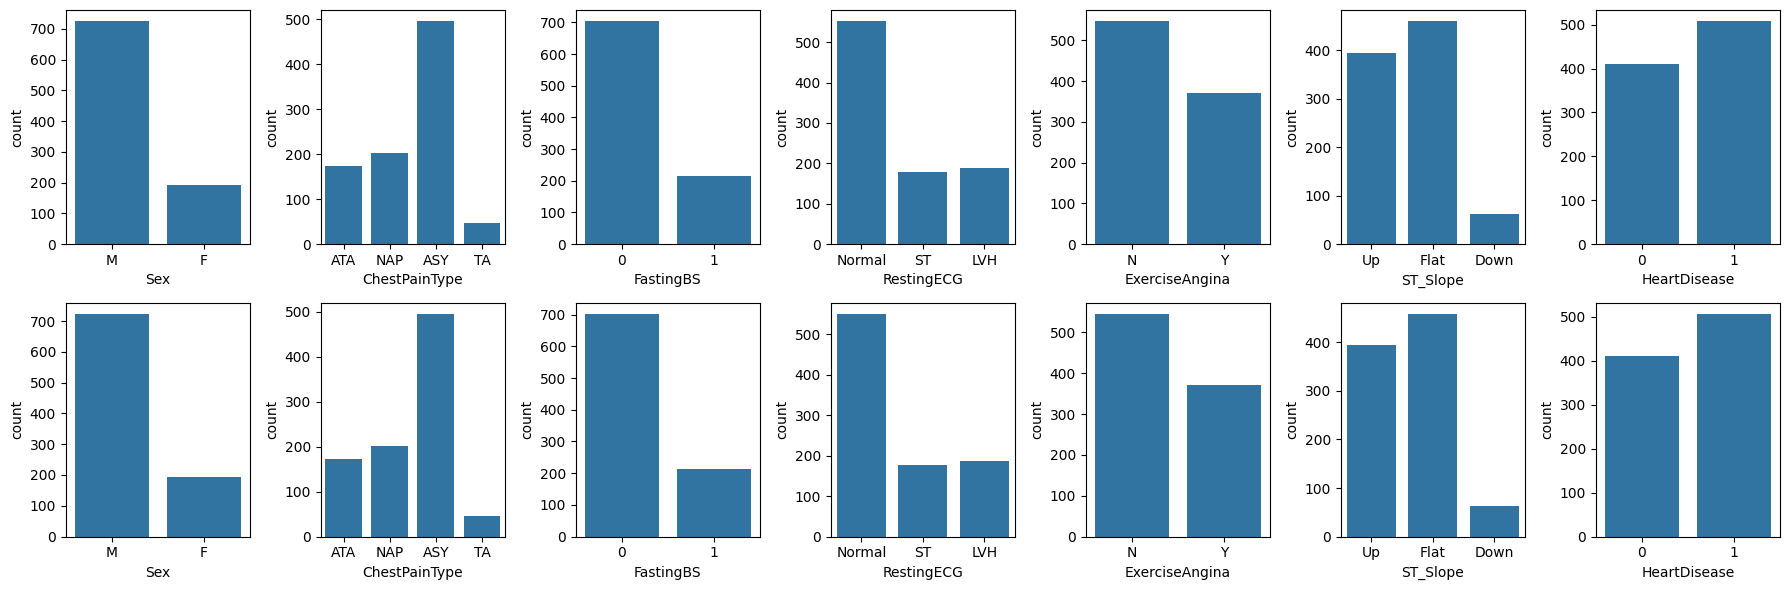

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 7, figsize=(18,6))
for i, col in enumerate(qual_cols):
  sns.countplot(
      data, 
      x = col,
      ax = axes[0,i]
  )
  sns.countplot(
      data.query(" RestingBP > 0"), 
      x = col,
      ax = axes[1,i]
  )

plt.tight_layout()

- 1 -**Resting BP and Old peak are under MCAR category Because When we remove the missing value columns it doesn't affect any columns espescially the target**

In [119]:
# Handling missing values MCAR
data['RestingBP'] = data['RestingBP'].fillna(data['RestingBP'].median())
data['Oldpeak'] = data['Oldpeak'].fillna(data['Oldpeak'].median())

- 1 **However if we remove the missing values of cholesterol it will affected the heart disease columns and causes bias when we do modelling which is under MAR Category**

In [120]:
# Handling missing values and invalid values for MAR
data['Cholesterol'] = data.groupby(['HeartDisease', 'Sex'])['Cholesterol'].transform(lambda x: x.fillna(x.median()))

In [121]:
data.describe()   

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,244.341503,136.809368,0.909804
std,9.432617,17.990127,53.475972,25.460334,1.040160
min,28.000000,80.000000,85.000000,60.000000,0.000000
25%,47.000000,120.000000,214.000000,120.000000,0.000000
50%,54.000000,130.000000,243.000000,138.000000,0.600000
75%,60.000000,140.000000,269.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


In [122]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
outlier_list = []

for col in numeric_cols:
    Q1, Q3 = data[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data[col] < lower) | (data[col] > upper)).sum()
    print(f"{col}: {n_out} outliers")
    if n_out > 0:
        outlier_list.append(col)

print(outlier_list)

Age: 0 outliers
RestingBP: 27 outliers
Cholesterol: 38 outliers
MaxHR: 2 outliers
Oldpeak: 15 outliers
['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


**C. General Information:**

- Visualize if cholesterol is correlated with age or not.
- Visualize if there is any chest pain type that strongly links to heart disease status or not.
- Visualize if diabetes is correlated with heart disease status or not.

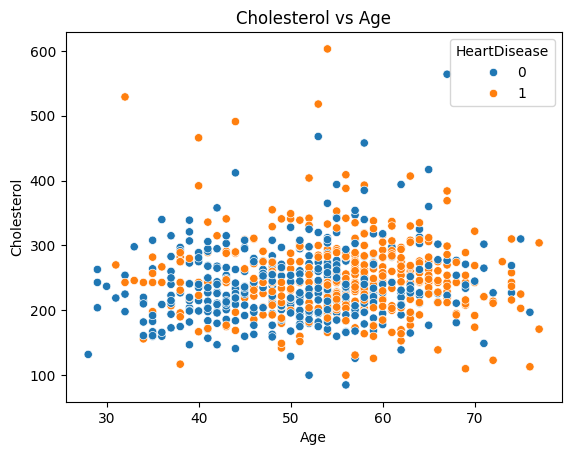

                  Age  Cholesterol
Age          1.000000     0.050997
Cholesterol  0.050997     1.000000


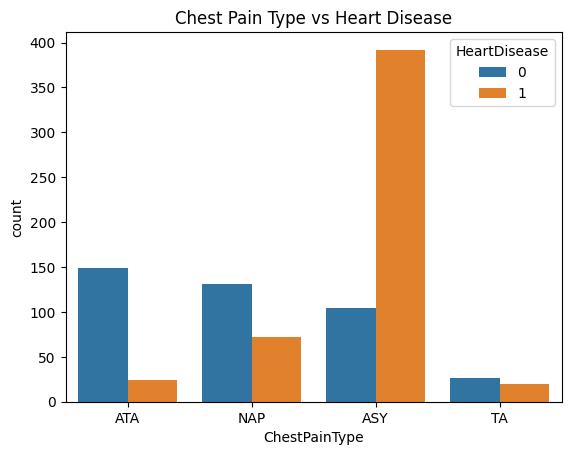

HeartDisease          0         1
ChestPainType                    
ASY            0.209677  0.790323
ATA            0.861272  0.138728
NAP            0.645320  0.354680
TA             0.565217  0.434783


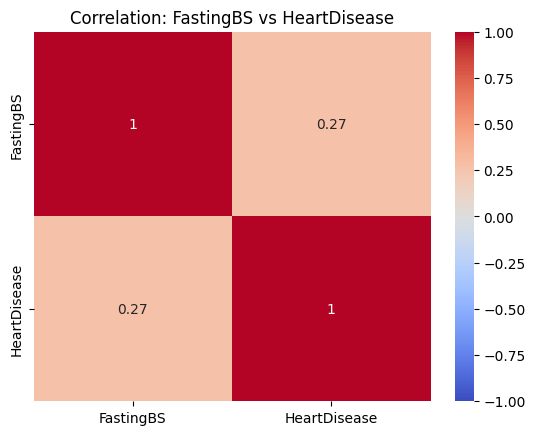

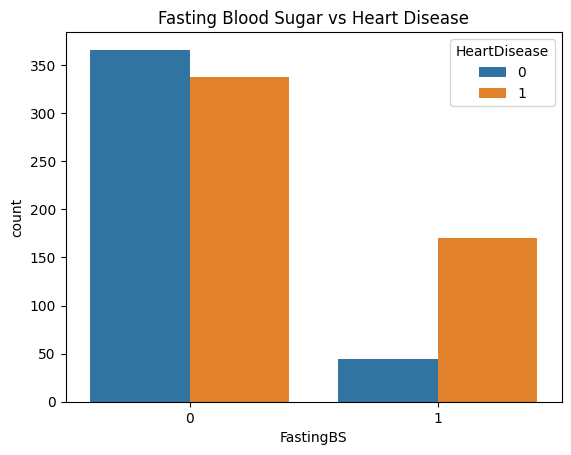

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.scatterplot(data=data, x='Age', y='Cholesterol', hue='HeartDisease')
plt.title('Cholesterol vs Age')
plt.show()
print(data[['Age', 'Cholesterol']].corr())


sns.countplot(data=data, x='ChestPainType', hue='HeartDisease')
plt.title('Chest Pain Type vs Heart Disease')
plt.show()
print(pd.crosstab(data['ChestPainType'], data['HeartDisease'], normalize='index'))



sns.heatmap(data[['FastingBS','HeartDisease']].astype(float).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: FastingBS vs HeartDisease')
plt.show()

sns.countplot(data=data, x='FastingBS', hue='HeartDisease')
plt.title('Fasting Blood Sugar vs Heart Disease')
plt.show()


- **Age has no corelation with Cholesterol.**
- **ASY has strongest links with Heart Disease among all of the Chestpain Types**
- **Yes, FastingBS shows a positive correlation with HeartDisease r = 0.27. This is a moderate-to-weak but clearly non-zero positive correlation patients with elevated fasting blood sugar (FastingBS = 1) are more likely to have heart disease.**


## **2. Kaggle [AutoMPG dataset](https://www.kaggle.com/datasets/uciml/autompg-dataset){target="_blank"}**

- Your job is to address if there is any columns containing missing values, invalid values or outliers or not?
- How would you handle the missing values if there is any?

In [124]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")
auto = pd.read_csv(path + '/auto-mpg.csv')
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [125]:
auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [126]:
auto['horsepower'] = pd.to_numeric(auto['horsepower'], errors='coerce')

In [127]:
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

outlier_list_auto = []

for col in numeric_cols:
    Q1, Q3 = auto[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((auto[col] < lower) | (auto[col] > upper)).sum()
    print(f"{col}: {n_out} outliers ({lower:.1f} to {upper:.1f})")
    if n_out > 0:
        outlier_list_auto.append(col)

print("\nColumns with outliers:", outlier_list_auto)

mpg: 1 outliers (0.2 to 46.2)
cylinders: 0 outliers (-2.0 to 14.0)
displacement: 0 outliers (-132.4 to 498.6)
horsepower: 10 outliers (-1.5 to 202.5)
weight: 0 outliers (147.4 to 5684.4)
acceleration: 7 outliers (8.8 to 22.2)

Columns with outliers: ['mpg', 'horsepower', 'acceleration']


**There are three outliers columns which are ['mpg', 'horsepower', 'acceleration']**

In [128]:
auto.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [129]:
auto['horsepower'] = auto['horsepower'].fillna(auto['horsepower'].median())

In [130]:
auto.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

# **Further Reading**

- `Pandas` python library: [https://pandas.pydata.org/docs/getting_started/index.html#getting-started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started)

- `Pandas Cheatsheet`: [https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)

- `10 Minute to Pandas`: [https://pandas.pydata.org/docs/user_guide/10min.html](https://pandas.pydata.org/docs/user_guide/10min.html)

- `Some Pandas Lession`: [https://www.kaggle.com/learn/pandas](https://pandas.pydata.org/docs/user_guide/10min.html)